**Business Problem**

Customer churn is a major revenue risk for telecom companies. Retaining customers is often cheaper than acquiring new ones. The goal of this analysis is to identify patterns in customer behavior that signal churn risk and to derive actionable retention strategies.

**Data Overview**

The dataset contains customer demographic information, service usage, billing details, and contract types. The target variable is whether the customer churned.

**Key Questions**

1. Which customer segments churn the most?
2. Does pricing influence churn?
3. Does customer tenure impact retention?
4. Which services correlate with customer loyalty?
5. Can we predict churn risk from customer attributes?


In [ ]:
import pandas as pd

#loading dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

#showing first rows
df.head()


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In this dataset the target variable of the company is that the customers are leaving
### target is to answer the question who leaves and why

In [5]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [7]:
pd.crosstab(df["Contract"],df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


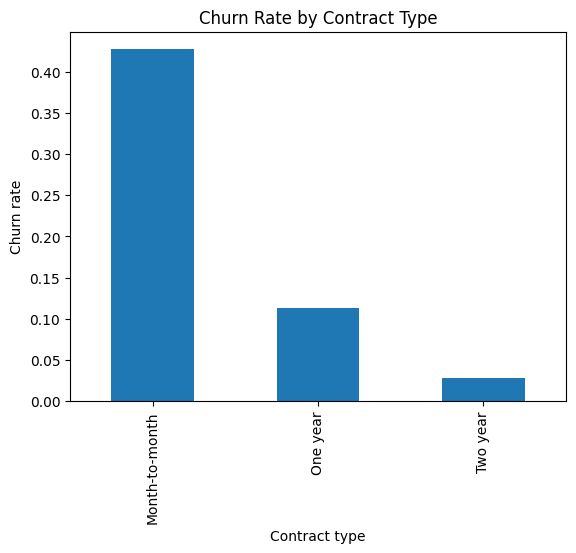

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# churn rate by contract
contract_churn = df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack()

contract_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn rate")
plt.xlabel("Contract type")
plt.show()

Customers on month-to-month contracts show significantly higher churn compared to those on longer contracts. This suggests that contract commitment plays a major role in retention. Encouraging customers to shift toward annual plans could reduce churn risk and stabilize revenue.


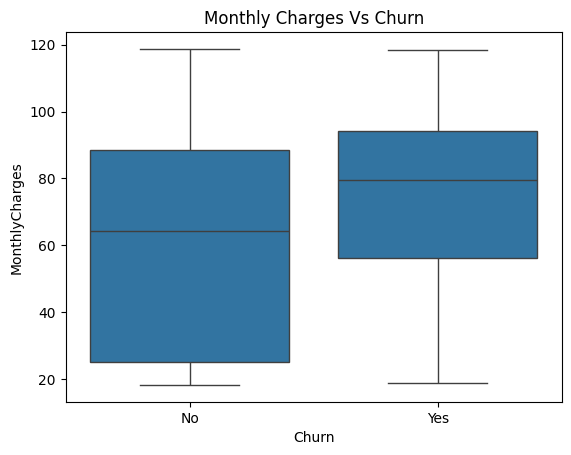

In [9]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges Vs Churn")
plt.show()

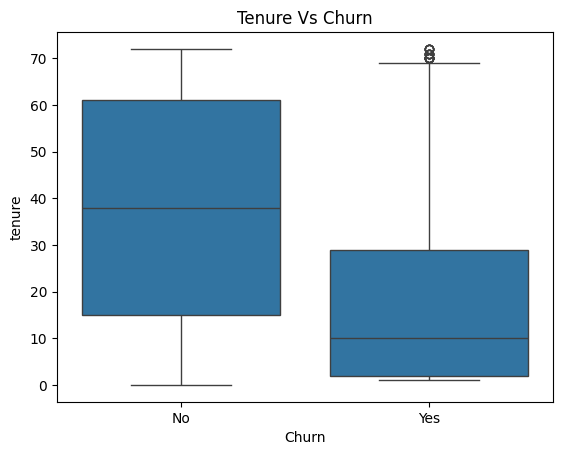

In [11]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure Vs Churn")
plt.show()

In [12]:
# Convert churn to numeric
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

# Drop customer ID
df_model = df.drop("customerID", axis=1)

# Convert categorical variables to dummy variables
df_model = pd.get_dummies(df_model, drop_first=True)

df_model.head()

,SeniorCitizen,tenure,MonthlyCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,TotalCharges_995.35,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9
0,0,1,29.85,0,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,0,34,56.95,0,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,2,53.85,1,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,45,42.30,0,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,0,2,70.70,1,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# separate features and target
x = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

# split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

#predictions
y_pred = model.predict(X_test_scaled)

# results
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1036
           1       0.61      0.51      0.56       373

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.78      1409



In [18]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["abs_coef"] = feature_importance["Coefficient"].abs()
feature_importance = feature_importance.sort_values("abs_coef", ascending=False)

feature_importance.head(10)


,Feature,Coefficient,abs_coef
16,DeviceProtection_Yes,-1.152366,1.152366
1,tenure,-1.141696,1.141696
9,InternetService_Fiber optic,1.109458,1.109458
22,StreamingMovies_Yes,1.055081,1.055081
14,OnlineBackup_Yes,-0.767869,0.767869
27,PaymentMethod_Electronic check,0.751158,0.751158
24,Contract_Two year,-0.616330,0.616330
28,PaymentMethod_Mailed check,0.554902,0.554902
18,TechSupport_Yes,-0.496901,0.496901
2,MonthlyCharges,0.492362,0.492362


**Key Insights**

Customers on month-to-month contracts churn significantly more than those on longer contracts.

New customers are far more likely to churn than long-tenured ones.
Higher monthly charges correlate with increased churn risk.
Customers using electronic payment methods show elevated churn probability.

Service bundles such as tech support and device protection are associated with stronger retention.

**Business Recommendations**

Encourage longer contract adoption through incentives.
Focus retention efforts during the first year of service.
Offer pricing reviews or discounts to high-bill customers.
Promote bundled services to increase perceived value.
Improve onboarding experience for new customers.

**Conclusion**

This analysis demonstrates that churn risk is strongly influenced by contract flexibility, customer tenure, pricing, and service engagement. Customers with shorter contracts, higher monthly charges, and limited service bundles show the highest churn probability. These findings highlight the importance of early customer retention strategies, value-based pricing, and bundled service offerings in reducing churn and stabilizing revenue.